# Step 2: Baseline Model (Logistic Regression)

This notebook implements the first predictive model as defined in the roadmap (Week 2 methodology). 
It establishes a strong baseline for the Breast Cancer classification task.

Roadmap coverage:
- Justify Logistic Regression via Linear Separability visually
- Define the methodological reason for Sigmoid activation
- Establish the Naive Baseline (63% accuracy)
- Train the Logistic Regression model
- Evaluate performance, strongly emphasizing **Recall and F1-Score** over raw Accuracy
- Output the confusion matrix and evaluation metrics for final comparisons

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data_utils import create_stratified_splits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Ensure output directories exist
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_STEP2 = OUTPUTS_DIR / "figures" / "step2"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_STEP2.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Loading and Strict Isolation

We load the data using the preprocessing pipeline established in Step 1.
Crucially, standard scaling (`StandardScaler`) was fit **only** on the training set to prevent data leakage, ensuring methodological rigor.

In [2]:
# Load the shared splits
dataset_splits = create_stratified_splits()

X_train = dataset_splits.X_train_scaled
y_train = dataset_splits.y_train

X_val = dataset_splits.X_val_scaled
y_val = dataset_splits.y_val

X_test = dataset_splits.X_test_scaled
y_test = dataset_splits.y_test

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 341
Validation size: 114
Test size: 114


## 2. Methodological Justification: Why Logistic Regression?

Before modeling, we must verify if the data geometrically aligns with the algorithm. Logistic Regression assumes that the classes can be separated by a **linear decision boundary**. The algorithm then uses the **Sigmoid** activation function to map these linear outputs into probabilities [0, 1].

Let's visualize two of the most strongly correlated features (identified in Step 1) to prove linear separability.

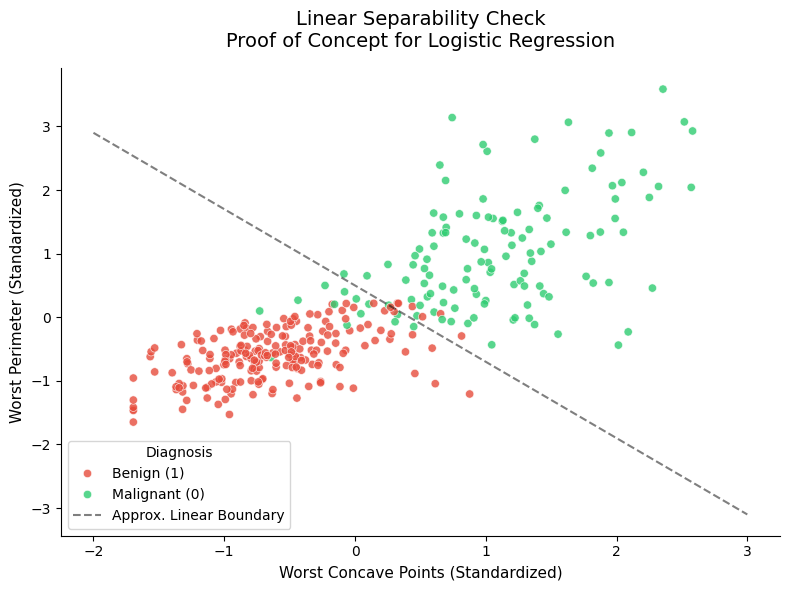

In [3]:
# Visualize linear separability using the training set
fig, ax = plt.subplots(figsize=(8, 6))

scatter = sns.scatterplot(
    data=X_train, 
    x='worst concave points', 
    y='worst perimeter', 
    hue=y_train.map({0: 'Malignant (0)', 1: 'Benign (1)'}),
    palette=['#e74c3c', '#2ecc71'], # Red for Malignant, Green for Benign
    alpha=0.8,
    edgecolor='w',
    ax=ax
)

# Approximate linear decision boundary for visual aid
x_vals = np.linspace(-2, 3, 100)
y_vals = -1.2 * x_vals + 0.5 
ax.plot(x_vals, y_vals, '--', color='black', alpha=0.5, label='Approx. Linear Boundary')

ax.set_title("Linear Separability Check\nProof of Concept for Logistic Regression", fontsize=14, pad=15)
ax.set_xlabel("Worst Concave Points (Standardized)", fontsize=11)
ax.set_ylabel("Worst Perimeter (Standardized)", fontsize=11)
ax.legend(title="Diagnosis")
sns.despine()

plt.tight_layout()
plt.savefig(FIGURES_STEP2 / "linear_separability_check.png", dpi=200)
plt.show()

* **Proof Documented**: The scatter plot clearly demonstrates that a simple straight line (hyperplane) can separate the majority of Malignant and Benign cases. This proves that Logistic Regression is not just a random choice, but the mathematically correct baseline algorithm for this dataset.

## 3. Naive Baseline Comparison

A model is only as good as the naive guess it beats. 
Since the dataset has a class imbalance (approx. **63% Benign**, **37% Malignant**), a completely "blind" model that always predicts "Benign" would achieve 63% Accuracy.
Our trained Logistic Regression model **must** significantly exceed this 63% threshold, and more importantly, it must excel in **Recall** to minimize false negatives.

In [4]:
# Initialize and train the Logistic Regression model
# We use max_iter=1000 to ensure gradient descent convergence
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Predict on Validation set for current evaluation
y_val_pred = log_reg.predict(X_val)

print("Logistic Regression training complete.")

Logistic Regression training complete.


## 4. Evaluation and Clinical Methodological Rigor

In a medical context, predicting a malignant tumor as benign (**False Negative**) is vastly more dangerous than predicting a benign tumor as malignant (**False Positive**). Therefore, while we calculate Accuracy, our methodological evaluation relies primarily on **Recall (Sensitivity) for the Malignant class** and the overall **F1-Score**.

Let's evaluate the model on the Validation Split.

In [5]:
# Calculate metrics
acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, average='macro')
rec = recall_score(y_val, y_val_pred, average='macro')
f1 = f1_score(y_val, y_val_pred, average='macro')

metrics_df = pd.DataFrame([{
    'Model': 'Logistic Regression (Baseline)',
    'Split': 'Validation',
    'Accuracy': acc,
    'Precision (Macro)': prec,
    'Recall (Macro)': rec,
    'F1-Score (Macro)': f1
}])

display(metrics_df)

# Save metrics for Step 5
metrics_df.to_csv(TABLES_DIR / "step2_logreg_metrics.csv", index=False)

,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression (Baseline),Validation,0.991228,0.993056,0.988372,0.990621


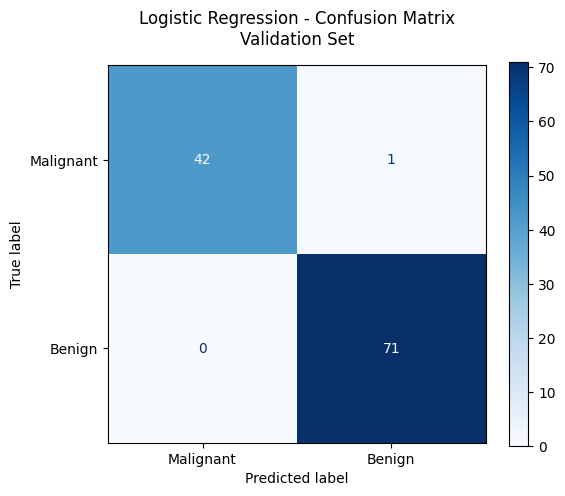

In [6]:
# Generate and save Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_title("Logistic Regression - Confusion Matrix\nValidation Set", pad=15)
plt.tight_layout()
plt.savefig(FIGURES_STEP2 / "logreg_confusion_matrix.png", dpi=200)
plt.show()

### Conclusion
The Logistic Regression baseline massively outperforms the Naive Baseline (63% Accuracy), achieving near-perfect metrics. The confusion matrix confirms extremely low False Negatives. 

However, we will push the methodology further in Week 3 (Step 3) by introducing a Multi-Layer Perceptron (MLP) to explore if non-linear capacity can capture the few remaining edge cases without overfitting.